In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [2]:
from student_env import MathTutorEnv, state_to_index
env = MathTutorEnv()
state = env.reset()
print("Initial state:", state)
next_state, reward, done, info = env.step(0)
print("Next state:", next_state)
print("Reward:", reward)
print("Done:", done)
print("Info:", info)

Initial state: (1, 0)
Next state: (1, 0)
Reward: 1.1199999999999997
Done: False
Info: {'correct': np.True_, 'add_skill': np.float64(0.5217481124360124), 'sub_skill': np.float64(0.24774384842195754), 'prob_correct': np.float64(0.4317481124360124), 'learning_gain': np.float64(0.039999999999999925), 'balance_gain': np.float64(-0.04000000000000001)}


In [3]:
from q_learning import train_q_learning
q_table, q_results = train_q_learning()
print(q_table)
print("Average reward in last 100 episodes:", np.mean(q_results["rewards"][-100:]))
print("Average accuracy in last 100 episodes:", np.mean(q_results["accuracy"][-100:]))

[[11.1558243  11.73628788]
 [14.82393137 15.89732296]
 [17.14602316 17.62494935]
 [16.14250368 14.99704693]
 [15.04204791 15.37515152]
 [16.75268027 17.29658772]
 [17.77084088 17.09970631]
 [17.98140577 17.50354878]
 [18.41209458 17.89598542]]
Average reward in last 100 episodes: 20.70683257086953
Average accuracy in last 100 episodes: 0.6813333333333333


In [4]:
from baselines import run_random_baseline, run_weakest_skill_baseline
random_rewards = run_random_baseline()
weakest_rewards = run_weakest_skill_baseline()
print("Q-learning:", np.mean(q_results["rewards"][-100:]))
print("Random:", np.mean(random_rewards))
print("Weakest:", np.mean(weakest_rewards))

Q-learning: 20.70683257086953
Random: 16.25394558855105
Weakest: 15.772530204596167


## Why Add SARSA

Q-learning already outperforms baseline methods, showing that reinforcement learning is effective in this setting.

We introduce SARSA to further explore whether a different learning strategy can improve performance.

While Q-learning is off-policy, SARSA is on-policy and learns from actual actions taken during exploration. This difference may lead to more stable behavior in a stochastic tutoring environment.

We compare the two methods to better understand which approach is more suitable.

In [5]:
from sarsa import train_sarsa
sarsa_table, sarsa_results = train_sarsa()
print(sarsa_table)
print("SARSA average reward in last 100 episodes:", np.mean(sarsa_results["rewards"][-100:]))
print("SARSA average accuracy in last 100 episodes:", np.mean(sarsa_results["accuracy"][-100:]))

[[10.07400514 10.85198777]
 [12.89372032 13.32388125]
 [15.15822013 15.32918592]
 [14.14085262 13.15902447]
 [14.63961343 14.19926286]
 [16.56312563 17.11687583]
 [16.299373   15.66242317]
 [16.92046931 16.31552359]
 [14.44470208 12.81714852]]
SARSA average reward in last 100 episodes: 19.756907419469602
SARSA average accuracy in last 100 episodes: 0.655


In [6]:
print("Q-learning:", np.mean(q_results["rewards"][-100:]))
print("SARSA:", np.mean(sarsa_results["rewards"][-100:]))
print("Random:", np.mean(random_rewards))
print("Weakest:", np.mean(weakest_rewards))

Q-learning: 20.70683257086953
SARSA: 19.756907419469602
Random: 16.25394558855105
Weakest: 15.772530204596167


In [7]:
q_table, q_results = train_q_learning()
sarsa_table, sarsa_results = train_sarsa()
random_rewards = run_random_baseline()
weakest_rewards = run_weakest_skill_baseline()

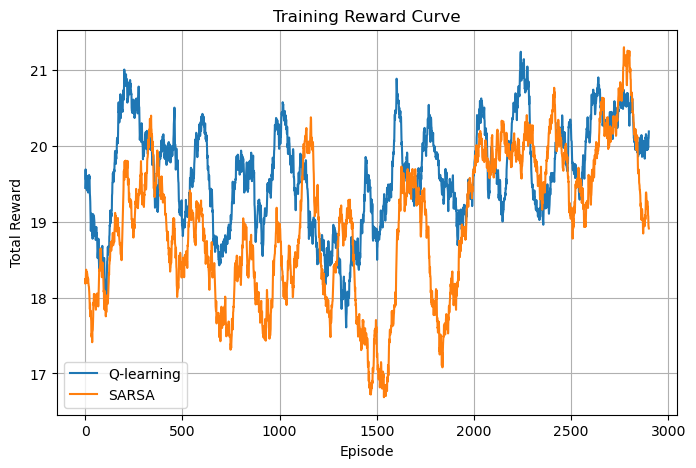

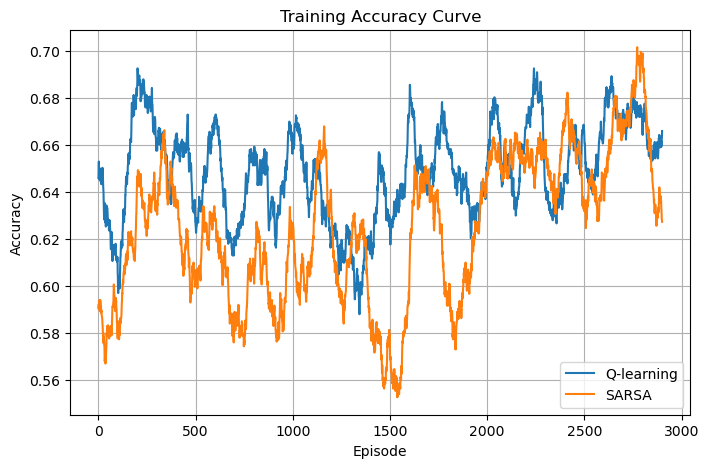

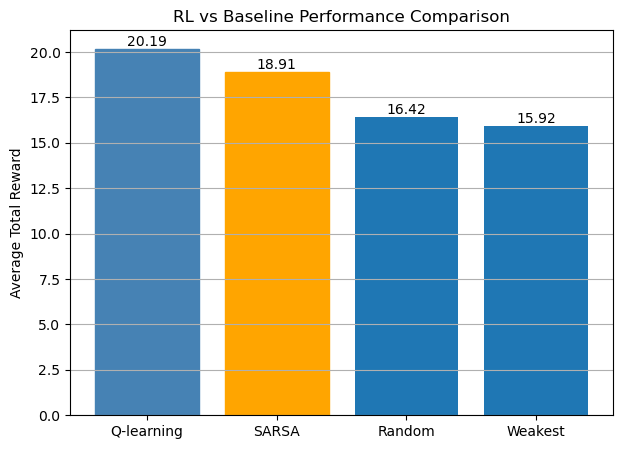

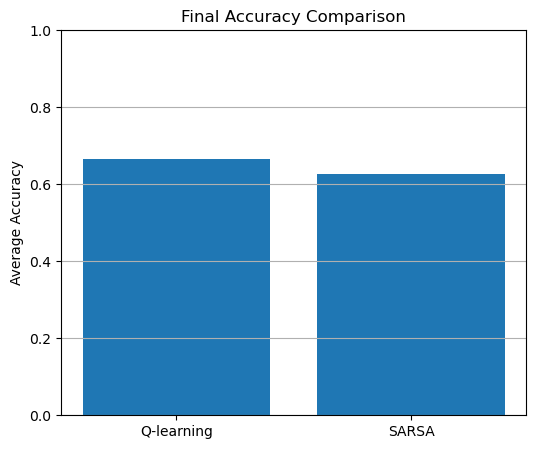


Learned Policy: Q-learning
----------------------------------------
Addition: Low, Subtraction: Low -> Choose Addition
Addition: Low, Subtraction: Medium -> Choose Subtraction
Addition: Low, Subtraction: High -> Choose Subtraction
Addition: Medium, Subtraction: Low -> Choose Addition
Addition: Medium, Subtraction: Medium -> Choose Addition
Addition: Medium, Subtraction: High -> Choose Subtraction
Addition: High, Subtraction: Low -> Choose Addition
Addition: High, Subtraction: Medium -> Choose Subtraction
Addition: High, Subtraction: High -> Choose Subtraction

Learned Policy: SARSA
----------------------------------------
Addition: Low, Subtraction: Low -> Choose Subtraction
Addition: Low, Subtraction: Medium -> Choose Subtraction
Addition: Low, Subtraction: High -> Choose Subtraction
Addition: Medium, Subtraction: Low -> Choose Addition
Addition: Medium, Subtraction: Medium -> Choose Subtraction
Addition: Medium, Subtraction: High -> Choose Addition
Addition: High, Subtraction: Low -

In [8]:
from evaluation import (
    plot_training_rewards,
    plot_training_accuracy,
    plot_policy_comparison,
    plot_accuracy_comparison,
    print_learned_policy
)

# 1. RL training curves
plot_training_rewards(q_results, sarsa_results)
plot_training_accuracy(q_results, sarsa_results)

# 2. RL vs Baseline comparison
plot_policy_comparison(
    q_results,
    sarsa_results,
    random_rewards,
    weakest_rewards
)

# 3. Accuracy comparison between RL models
plot_accuracy_comparison(q_results, sarsa_results)

# 4. Print learned policies
print_learned_policy(q_table, "Q-learning")
print_learned_policy(sarsa_table, "SARSA")